#Import Library

In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

#Read Data

In [44]:
df = pd.read_excel("https://raw.github.com/dewitrilestari/Portofolio/main/Forecasting/Merge%20Data/Juli%202024%20-%20Juli%202026.xlsx")

In [45]:
df

,Tanggal,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR
0,2024-07-14,18.8,30.7,24.1,74.0,0.0,7.5,4.0,130,2,W
1,2024-07-15,19.8,30.5,24.3,74.0,0.0,8.0,6.0,180,2,S
2,2024-07-16,19.6,30.5,24.6,77.0,0.0,8.0,5.0,280,2,W
3,2024-07-17,21.6,30.6,25.7,80.0,0.0,8.0,4.0,260,2,W
4,2024-07-18,21.3,31.7,25.6,79.0,0.0,8.0,3.0,210,2,W
...,...,...,...,...,...,...,...,...,...,...,...
724,2026-07-08,22.3,31.8,25.9,68.8,0.0,8.0,5.1,260,3,SW
725,2026-07-09,19.0,29.6,24.3,71.0,0.0,7.1,4.1,260,2,S;W
726,2026-07-10,19.4,31.9,24.8,63.8,0.0,7.9,3.1,260,2,S
727,2026-07-11,20.3,31.4,25.0,64.0,0.0,7.3,2.6,260,1,C


#Data Checking

##Data Type

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Tanggal  729 non-null    datetime64[ns]
 1   TN       729 non-null    float64       
 2   TX       729 non-null    float64       
 3   TAVG     729 non-null    float64       
 4   RH_AVG   729 non-null    float64       
 5   RR       729 non-null    float64       
 6   SS       729 non-null    float64       
 7   FF_X     729 non-null    float64       
 8   DDD_X    729 non-null    int64         
 9   FF_AVG   729 non-null    int64         
 10  DDD_CAR  729 non-null    object        
dtypes: datetime64[ns](1), float64(7), int64(2), object(1)
memory usage: 62.8+ KB


##Statistic

In [47]:
df.describe()

,Tanggal,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG
count,729,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000
mean,2025-07-13 00:00:00.000000256,23.101646,31.268176,26.404664,83.820713,8.188615,5.257064,4.500137,227.524005,1.886145
min,2024-07-14 00:00:00,18.000000,24.600000,23.200000,63.800000,0.000000,0.000000,2.000000,4.000000,0.000000
25%,2025-01-12 00:00:00,22.600000,30.600000,25.800000,80.000000,0.000000,3.200000,4.000000,210.000000,1.000000
50%,2025-07-13 00:00:00,23.200000,31.400000,26.400000,84.000000,0.000000,5.700000,4.000000,240.000000,2.000000
75%,2026-01-11 00:00:00,23.900000,32.100000,27.100000,87.000000,8.300000,7.700000,5.000000,260.000000,2.000000
max,2026-07-12 00:00:00,25.500000,36.800000,28.800000,97.000000,145.200000,8.000000,13.000000,360.000000,6.000000
std,NaN,1.180274,1.355565,0.968135,5.414008,17.447106,2.443978,1.424197,70.057863,0.700814


##Missing Value

In [48]:
df.isnull().sum()

,0
Tanggal,0
TN,0
TX,0
TAVG,0
RH_AVG,0
RR,0
SS,0
FF_X,0
DDD_X,0
FF_AVG,0


##Duplicate

In [49]:
df.duplicated().sum()

np.int64(0)

##Feature Selection

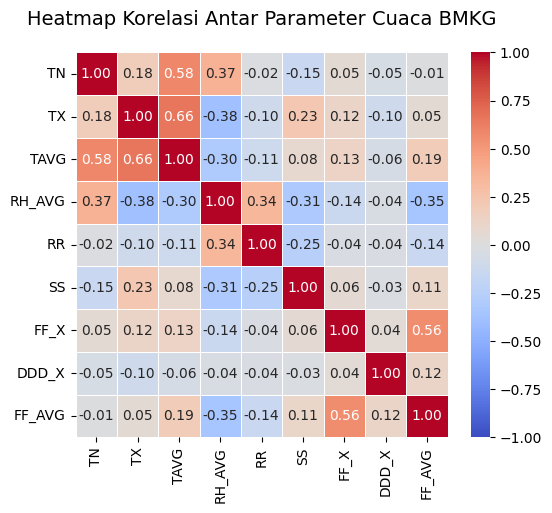

In [51]:
if 'RR' in df.columns:
    df['RR'] = df['RR'].clip(lower=0)
df_numeric = df.drop(columns=['Tanggal', 'DDD_CAR'], errors='ignore')
matriks_korelasi = df_numeric.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Heatmap Korelasi Antar Parameter Cuaca BMKG', fontsize=14, pad=20)
plt.show()

#EDA

##Time Series

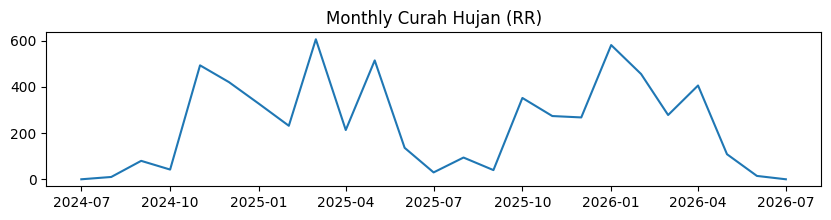

In [58]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

monthly_rr = df.groupby(pd.Grouper(key='Tanggal', freq='MS'))['RR'].sum()

plt.figure(figsize=(10, 2))
plt.plot(monthly_rr)
plt.title('Monthly Curah Hujan (RR)')
plt.show()

**Pola Musiman**
* Periode Musim Kemarau (Juli - September): Ditunjukkan oleh lembah grafik yang sangat rendah, mendekati $0$ mm. Ini terlihat jelas pada periode Juli - Oktober 2024, Juni - September 2025, dan kembali turun drastis di Mei - Juli 2026. Pada bulan-bulan ini, akumulasi hujan hampir tidak ada.
* Periode Musim Hujan (Oktober - Mei): Ditunjukkan oleh grafik yang naik drastis. Peningkatan curah hujan mulai terjadi sekitar bulan Oktober dan mencapai puncaknya di sekitar bulan Januari hingga April.

**Perbandingan Antar Tahun**
* Siklus 2024–2025: Curah hujan mulai meningkat di akhir 2024, sempat turun sedikit di awal 2025 (sekitar Februari), lalu melonjak ke puncak tertingginya di sekitar Maret 2025 dengan total curah hujan bulanan menembus $600$ mm.
* Siklus 2025–2026: Memiliki pola yang mirip, di mana hujan mulai naik di akhir 2025 dan mencapai puncak tertingginya di sekitar Januari 2026 dengan akumulasi mencapai hampir $600$ mm, sebelum akhirnya turun kembali menuju musim kemarau di pertengahan 2026.

##Data Distribution

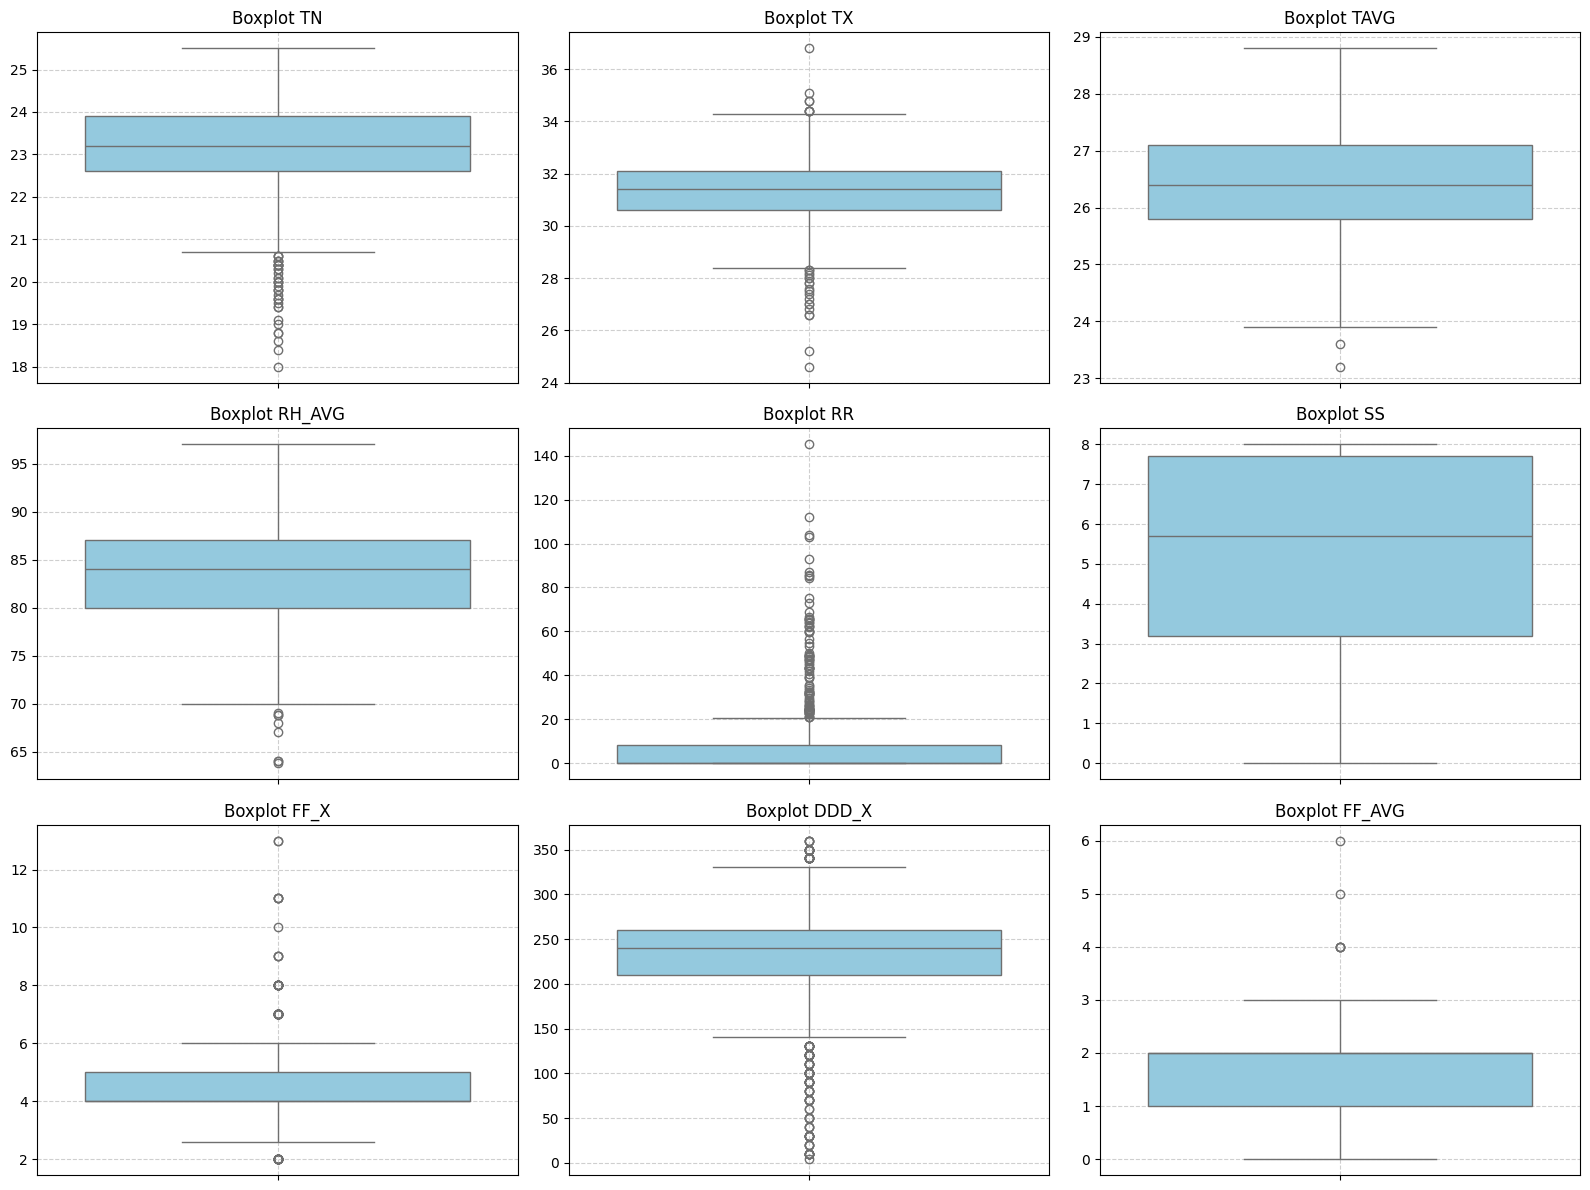

In [50]:
kolom_numerik = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
ringkasan_outliers = {}

for col in kolom_numerik:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    kondisi_outlier = (df[col] < batas_bawah) | (df[col] > batas_atas)
    jumlah_outliers = df[kondisi_outlier].shape[0]
    persentase = (jumlah_outliers / len(df)) * 100

    ringkasan_outliers[col] = [jumlah_outliers, f"{persentase:.2f}%"]

jumlah_kolom = len(kolom_numerik)
fig, axes = plt.subplots(nrows=(jumlah_kolom + 2) // 3, ncols=3, figsize=(16, 4 * ((jumlah_kolom + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot {col}', fontsize=12)
    axes[i].set_ylabel('')
    axes[i].grid(True, linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##Rolling Mean and Rolling Standard Deviation

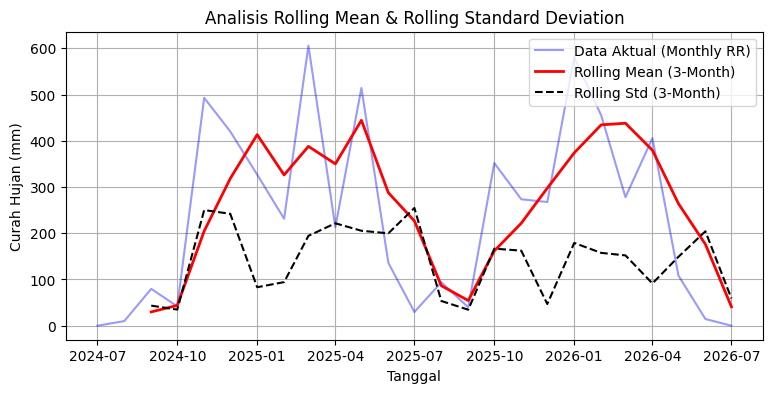

In [55]:
# Menghitung Rolling Mean & Rolling Std dengan jendela (window) 3 bulan
rolling_window = 3
rolling_mean = monthly_rr.rolling(window=rolling_window).mean()
rolling_std = monthly_rr.rolling(window=rolling_window).std()

# Visualisasi
plt.figure(figsize=(9, 4))
plt.plot(monthly_rr, label='Data Aktual (Monthly RR)', color='blue', alpha=0.4)
plt.plot(rolling_mean, label=f'Rolling Mean ({rolling_window}-Month)', color='red', linewidth=2)
plt.plot(rolling_std, label=f'Rolling Std ({rolling_window}-Month)', color='black', linestyle='--')

plt.title('Analisis Rolling Mean & Rolling Standard Deviation')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.grid(True)
plt.show()

**Rolling Mean**
* Pola Siklus Tahunan: Terlihat jelas ada dua gelombang puncak utama di grafik tersebut. Puncak pertama terjadi di sekitar awal tahun 2025 (Januari - April) dan puncak kedua terjadi di awal tahun 2026 (Januari - April). Ini menandakan periode puncak musim hujan harian yang terakumulasi.
* Lembah Tren: Garis merah merosot tajam hingga di bawah rentang 100 mm di sekitar bulan Juli - September baik pada tahun 2025 maupun 2026, yang menandakan periode musim kemarau.

**Rolling Standard Deviation**
* Volatilitas Tinggi (Garis Hitam Naik): Pada akhir 2024 (sekitar bulan November ke Desember), garis hitam naik drastis menyentuh angka 250. Artinya, pada bulan-bulan tersebut terjadi perubahan curah hujan yang sangat ekstrem dari bulan sebelumnya (misal dari bulan yang sangat kering langsung melompat ke bulan yang sangat basah). Hal yang sama berulang di pertengahan tahun 2025 (Maret - Juli).
* Volatilitas Rendah (Garis Hitam Turun): Di sekitar bulan Agustus - September 2025, garis hitam ikut drop ke bawah (di bawah 50). Ini berarti variasi antar bulan di periode tersebut sangat kecil. Udara dan cuacanya stabil secara konsisten, yaitu sama-sama kering/jarang hujan di masa kemarau.

##Moving Average

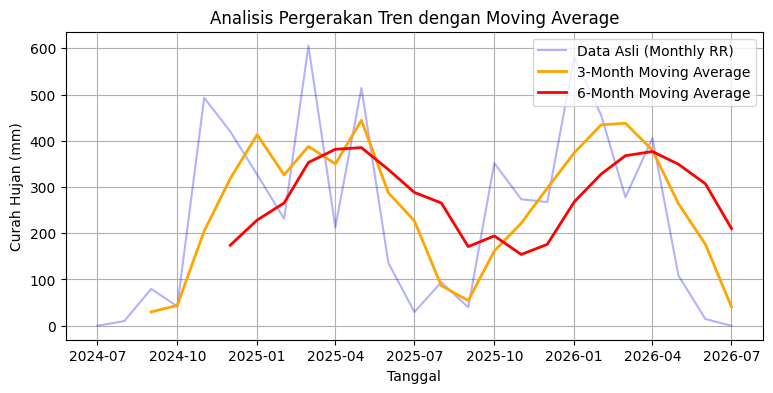

In [57]:
ma_3 = monthly_rr.rolling(window=3).mean()
ma_6 = monthly_rr.rolling(window=6).mean()

plt.figure(figsize=(9, 4))
plt.plot(monthly_rr, label='Data Asli (Monthly RR)', color='blue', alpha=0.3)
plt.plot(ma_3, label='3-Month Moving Average', color='orange', linewidth=2)
plt.plot(ma_6, label='6-Month Moving Average', color='red', linewidth=2)

plt.title('Analisis Pergerakan Tren dengan Moving Average')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.grid(True)
plt.show()

**3-Month Moving Average**
* Garis ini masih mengikuti lekukan fluktuasi jangka pendek, tetapi berhasil memotong puncak-puncak tajam yang ekstrem (misalnya puncak biru di atas 600 mm pada awal 2025 diredam menjadi sekitar 400 mm saja).
* Garis oranye ini sangat bagus untuk melihat perubahan tren musiman yang lebih cepat, seperti transisi dari musim kemarau ke musim hujan yang berjarak beberapa bulan saja.

**6-Month Moving Average**
* Garis merah terlihat jauh lebih halus, landai, dan bergeser agak ke kanan (mengalami lag / keterlambatan) dibanding garis lainnya. Hal ini terjadi karena matematika rata-rata memerlukan data 6 bulan ke belakang sebelum bisa membentuk satu titik baru.
* Garis merah ini mengabaikan fluktuasi bulanan yang kecil dan fokus memperlihatkan tren makro (tren jangka panjang tahunan). Iklim di wilayah ini memiliki dua gelombang siklus tahunan yang sangat masif dan teratur.

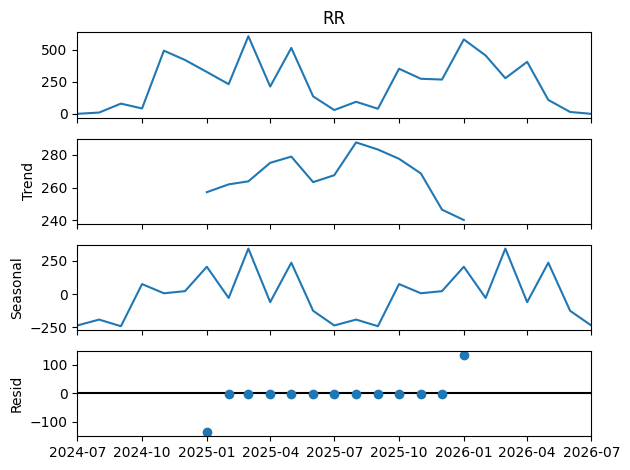

In [59]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

monthly_rr = df.groupby(pd.Grouper(key='Tanggal', freq='MS'))['RR'].sum()

decomp = seasonal_decompose(monthly_rr, model='additive', period=12)
decomp.plot()
plt.show()

**Analisis Tren**
* Garis tren naik bertahap dari paruh kedua tahun 2024 hingga mencapai puncak tertingginya di pertengahan tahun 2025 (sekitar Juli/Agustus 2025), lalu menukik turun secara konsisten menuju pertengahan tahun 2026.
* Iklim pada periode tahun 2025 cenderung memiliki intensitas curah hujan akumulatif yang lebih basah atau tinggi dibandingkan periode tahun 2024 dan 2026. Tren ini membantu model mendeteksi pergeseran jangka panjang melampaui perubahan bulan ke bulan.

**Analisis Seasonal**
* Bentuk gelombang yang identik dan berulang persis antara siklus tahun pertama (2024–2025) dan tahun kedua (2025–2026). Nilainya berosilasi di sekitar angka 0 (karena menggunakan model additive).
* Wilayah data ini memiliki karakteristik musim hujan dan kemarau yang sangat teratur. Pola naik-turun yang tajam ini menunjukkan transisi ekstrem yang terprediksi dari bulan ke bulan di setiap tahunnya.

**Analisis Residual**
* Mayoritas titik berada tepat di garis nol, yang berarti model dekomposisi berhasil mengekstrak pola tren dan musim secara sempurna. Namun, ada dua titik ekstrem: satu titik anomali negatif di awal 2025 (curah hujan turun mendadak lebih rendah dari normalnya) dan satu titik anomali positif kuat di awal 2026 (terjadi lonjakan curah hujan yang jauh lebih tinggi dari pola musim hujan normal).

#Train-Test Split

In [38]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'], dayfirst=True, errors='coerce')
df = df[(df['Tanggal'] >= '2024-07-14') & (df['Tanggal'] <= '2026-07-13')].reset_index(drop=True)

df['RR'] = df['RR'].clip(lower=0)

for lag in [1, 3, 7]:
    df[f'RR_lag_{lag}'] = df['RR'].shift(lag)

df['bulan'] = df['Tanggal'].dt.month
df['hari'] = df['Tanggal'].dt.day

df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['Tanggal', 'DDD_CAR', 'RR'], errors='ignore')
y = df['RR']

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

#Scaling

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Training Model

##SVM

In [98]:
model_svm = SVR(kernel='rbf', C=5.0, epsilon=0.1)
model_svm.fit(X_train_scaled, y_train)

SVR(C=5.0)

In [99]:
y_pred_svm = model_svm.predict(X_test_scaled)
y_pred_svm = np.clip(y_pred_svm, a_min=0, a_max=None)

In [100]:
mae_svm = mean_absolute_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))

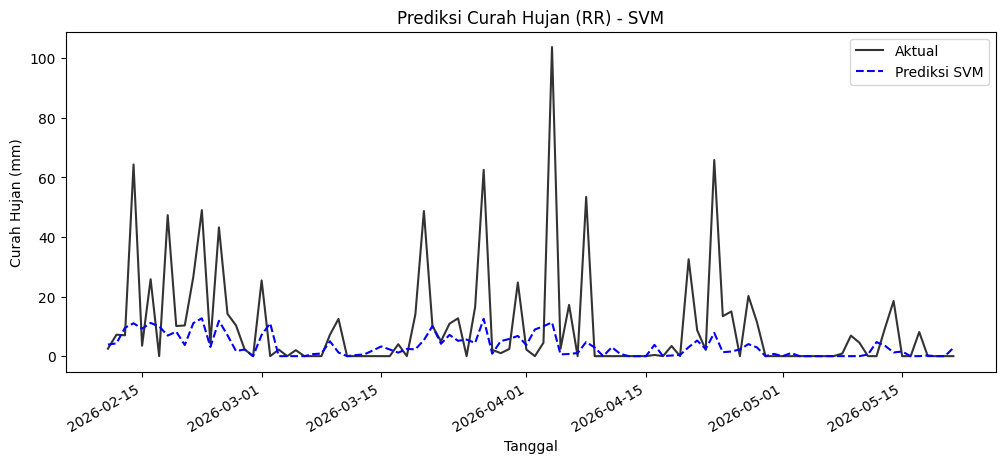

In [103]:
plt.figure(figsize=(12, 5))
plt.plot(dates_test.values[:100], y_test.values[:100], label='Aktual', color='black', alpha=0.8)
plt.plot(dates_test.values[:100], y_pred_svm[:100], label='Prediksi SVM', color='blue', linestyle='--')
plt.legend()
plt.title("Prediksi Curah Hujan (RR) - SVM")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.gcf().autofmt_xdate()
plt.show()

##Random Forest

In [93]:
model_rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, n_jobs=-1, random_state=42)

In [94]:
y_pred_rf = model_rf.predict(X_test_scaled)
y_pred_rf = np.clip(y_pred_rf, a_min=0, a_max=None)

In [95]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

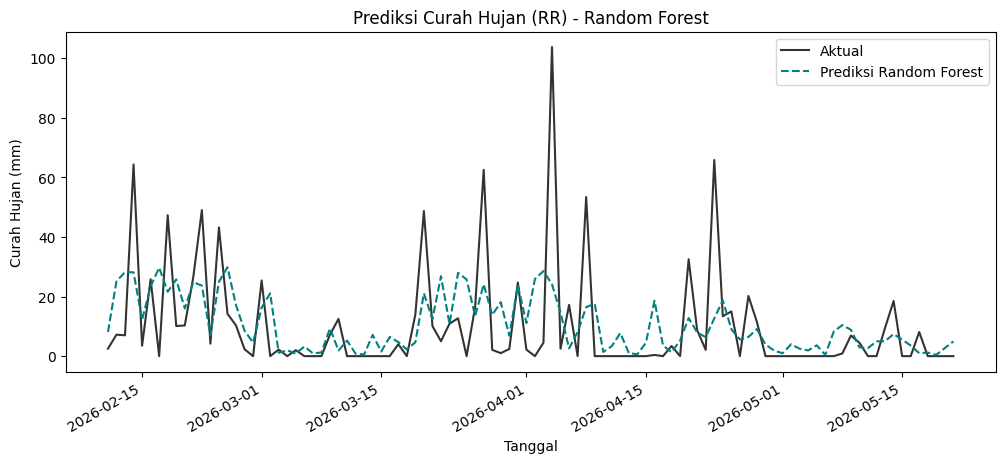

In [96]:
dates_test = df['Tanggal'].iloc[split_index:]

plt.figure(figsize=(12, 5))
plt.plot(dates_test.values[:100], y_test.values[:100], label='Aktual', color='black', alpha=0.8)
plt.plot(dates_test.values[:100], y_pred_rf[:100], label='Prediksi Random Forest', color='teal', linestyle='--')
plt.legend()
plt.title("Prediksi Curah Hujan (RR) - Random Forest")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.gcf().autofmt_xdate()
plt.show()

##XGBoost Regression

In [73]:
model_xgb = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
model_xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [74]:
y_pred_xgb = model_xgb.predict(X_test_scaled)
y_pred_xgb = np.clip(y_pred_xgb, a_min=0, a_max=None)

In [75]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

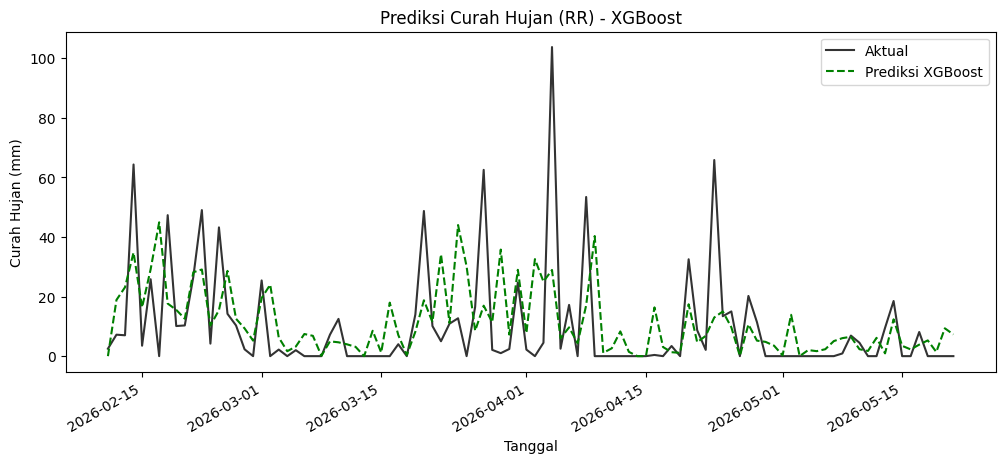

In [76]:
dates_test = df['Tanggal'].iloc[split_index:]

plt.figure(figsize=(12, 5))
plt.plot(dates_test.values[:100], y_test.values[:100], label='Aktual', color='black', alpha=0.8)
plt.plot(dates_test.values[:100], y_pred_xgb[:100], label='Prediksi XGBoost', color='green', linestyle='--')
plt.legend()
plt.title("Prediksi Curah Hujan (RR) - XGBoost")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.gcf().autofmt_xdate() # Merapikan posisi tanggal miring
plt.show()

##Light GBM

In [105]:
model_lgb = LGBMRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_seed=42, verbose=-1)
model_lgb.fit(X_train_scaled, y_train)

LGBMRegressor(learning_rate=0.05, max_depth=5, n_estimators=200, random_seed=42,
              verbose=-1)

In [106]:
y_pred_lgb = model_lgb.predict(X_test_scaled)
y_pred_lgb = np.clip(y_pred_lgb, a_min=0, a_max=None)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [107]:
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

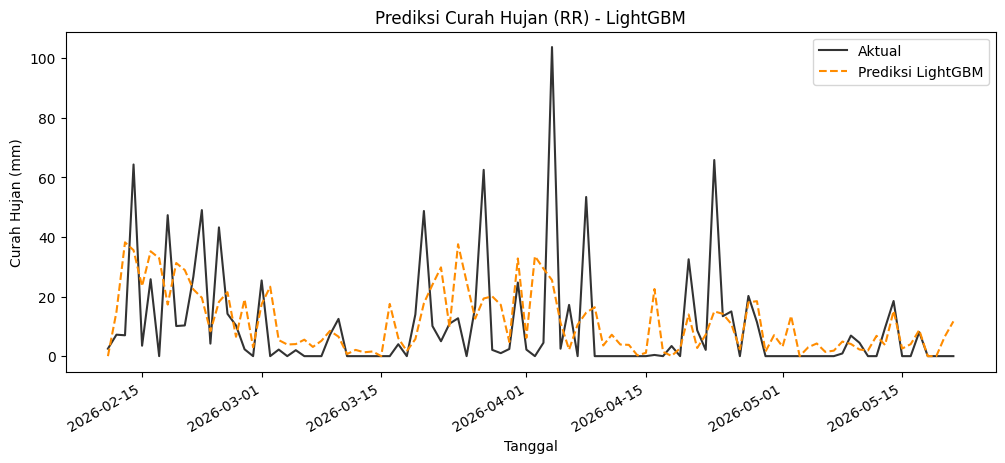

In [108]:
dates_test = df['Tanggal'].iloc[split_index:]

plt.figure(figsize=(12, 5))
plt.plot(dates_test.values[:100], y_test.values[:100], label='Aktual', color='black', alpha=0.8)
plt.plot(dates_test.values[:100], y_pred_lgb[:100], label='Prediksi LightGBM', color='darkorange', linestyle='--')
plt.legend()
plt.title("Prediksi Curah Hujan (RR) - LightGBM")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.gcf().autofmt_xdate()
plt.show()

##LSTM

In [83]:
X_train_3d = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_3d = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [84]:
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_3d.shape[1], X_train_3d.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train_3d, y_train, epochs=50, batch_size=16, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [85]:
y_pred_lstm = model_lstm.predict(X_test_3d).flatten()
y_pred_lstm = np.clip(y_pred_lstm, a_min=0, a_max=None)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [86]:
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

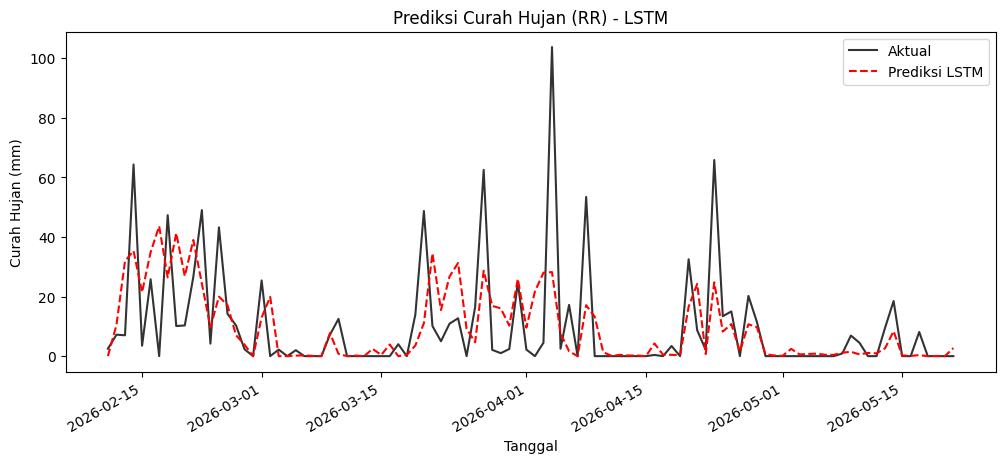

In [87]:
dates_test = df['Tanggal'].iloc[split_index:]

plt.figure(figsize=(12, 5))
plt.plot(dates_test.values[:100], y_test.values[:100], label='Aktual', color='black', alpha=0.8)
plt.plot(dates_test.values[:100], y_pred_lstm[:100], label='Prediksi LSTM', color='red', linestyle='--')
plt.legend()
plt.title("Prediksi Curah Hujan (RR) - LSTM")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.gcf().autofmt_xdate()
plt.show()

#Model Evaluation

In [109]:
def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Pastikan semua variabel prediksi Anda sudah siap
models_preds = {
    'XGBoost': y_pred_xgb,
    'SVM': y_pred_svm,
    'LSTM': y_pred_lstm,
    'Random Forest': y_pred_rf,
    'LightGBM': y_pred_lgb
}

mae_results = []
rmse_results = []
mape_results = []

for name, pred in models_preds.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = calculate_mape(y_test, pred)

    mae_results.append(mae)
    rmse_results.append(rmse)
    mape_results.append(mape)

df_evaluasi_akhir = pd.DataFrame({
    'MAE (mm)': mae_results,
    'RMSE (mm)': rmse_results,
    'MAPE (%)': mape_results
}, index=models_preds.keys())

display(df_evaluasi_akhir.round(3))

,MAE (mm),RMSE (mm),MAPE (%)
XGBoost,7.711,14.157,242.525
SVM,6.137,14.430,91.803
LSTM,6.627,12.857,162.595
Random Forest,7.274,13.103,238.386
LightGBM,8.128,14.057,262.985


Nilai MAPE di semua model sangat besar (bahkan di atas 100%) adalah hal yang sangat wajar dalam prediksi curah hujan harian. Pada hari-hari dengan hujan sangat rintik (misalnya aktual 1 mm) jika model memprediksi 3 mm (selisih hanya 2 mm), nilai MAPEnya langsung melonjak menjadi 200%.

**SVM**
* SVM memiliki MAE terendah (6.137 mm) dan MAPE paling kecil (91.803%)
* Nilai RMSE-nya sedikit lebih tinggi (14.430 mm), yang berarti sesekali SVM bisa kecolongan membuat tebakan yang meleset cukup jauh saat cuaca ekstrem tiba-tiba berubah.

**LSTM**
* LSTM memiliki RMSE terendah (12.857 mm). Karena formula RMSE memberikan penalti besar pada eror yang besar, nilai yang rendah ini membuktikan bahwa LSTM sangat bagus dalam meredam kesalahan prediksi yang fatal.
* MAE-nya sedikit di bawah SVM dan MAPEnya cukup tinggi (162.595%).

#Forecasting - LSTM

In [110]:
forecast_periods = [7, 14, 30]
max_forecast = max(forecast_periods)

In [112]:
last_input = X_test_scaled[-1].copy()
current_input_3d = np.reshape(last_input, (1, 1, len(last_input)))
future_predictions = []

In [115]:
for i in range(max_forecast):
    pred_1step = model_lstm.predict(current_input_3d, verbose=0).flatten()[0]
    pred_1step = max(0, pred_1step)
    future_predictions.append(pred_1step)

    new_input = np.roll(last_input, -1)
    new_input[-1] = pred_1step
    last_input = new_input
    current_input_3d = np.reshape(last_input, (1, 1, len(last_input)))

In [116]:
last_date = pd.to_datetime(df_filtered['Tanggal'].iloc[-1])
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=max_forecast, freq='D')

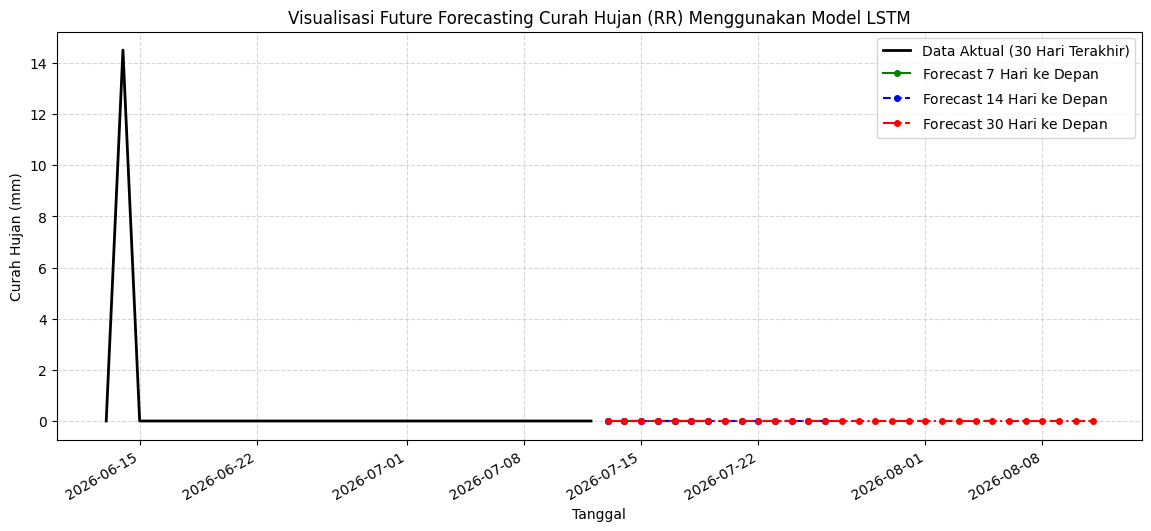

In [118]:
plt.figure(figsize=(14, 6))

dates_actual_plot = df_filtered['Tanggal'].iloc[-30:]
y_actual_plot = y_test.iloc[-30:] if len(y_test) >= 30 else y_test
plt.plot(dates_actual_plot, y_actual_plot, label='Data Aktual (30 Hari Terakhir)', color='black', linewidth=2)

colors = {7: 'green', 14: 'blue', 30: 'red'}
styles = {7: '-', 14: '--', 30: '-.'}

for days in forecast_periods:
    plt.plot(
        future_dates[:days],
        future_predictions[:days],
        label=r'$\text{Forecast }' + str(days) + r'\text{ Hari ke Depan}$',
        color=colors[days],
        linestyle=styles[days],
        marker='o',
        markersize=4
    )

plt.title("Visualisasi Future Forecasting Curah Hujan (RR) Menggunakan Model LSTM")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.gcf().autofmt_xdate()
plt.show()

#Download Model

In [121]:
model_lstm.save('model_lstm.keras')